### 전처리
- pdf 문서에서 텍스트와 이미지를 분리하여 추출하고 OpenAI를 이용해 이미지를 텍스트로 요약

In [1]:
import os
import fitz
import requests
import base64
from dotenv import load_dotenv
from openai import OpenAI
load_dotenv(override=True)
client = OpenAI()


In [2]:
# https://arxiv.org/pdf/1706.03762.pdf
pdf_url = 'https://arxiv.org/pdf/1706.03762.pdf'
pdf_path = 'sample_paper.pdf'
if not os.path.exists(pdf_path):
    response = requests.get(pdf_url)
    with open(pdf_path, 'wb') as f:
        f.write(response.content)
        print('다운로드 완료')
else:
    print(f"{pdf_path} 가 존재합니다.")

다운로드 완료


### PDF에서 텍스트와 이미지 추출

In [7]:
doc = fitz.open(pdf_path)
texts = []
images = []
output_img_dir = 'extracted_images'
os.makedirs(output_img_dir, exist_ok=True)

for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    # 텍스트 추출
    text = page.get_text()
    if text.strip():
        texts.append({'page':page_num, 'content':text})
    # 이미지 추출
    image_list = page.get_images(full=True)
    
    for image_index, img in enumerate(image_list):
        xref = img[0]
        base_image = doc.extract_image(xref)
        image_bytes = base_image['image']
        image_ext = base_image['ext']

        image_filename = f'page{page_num}_img{image_index+1}.{image_ext}'
        image_filepath = os.path.join(output_img_dir, image_filename)

        with open(image_filepath, 'wb') as f:
            f.write(image_bytes)
        
        images.append({
            'page': page_num +1,
            'filename': image_filepath,
            'bytes': image_bytes,
            'ext': image_ext
        })

print(f'추출완료 : 텍스트 : {len(texts)}페이지, 이미지:{len(images)}개')



추출완료 : 텍스트 : 15페이지, 이미지:3개


### 이미지 요약 gpt-5.4-nano
- 이미지에 대한 상세 설명을 텍스트로 요약

In [ ]:
def encode_image(image_bytes):
    return base64.b64encode(image_bytes).decode('utf-8')

image_summaries = []
for img_meta in images:
    base64_image = encode_image(img_meta['bytes'])
    ext = img_meta['ext']
    
    if ext.lower() == 'jb2':
        ext = 'jpeg'
    mime_type = f'image/{ext}' if ext.lower() != "jpg" else 'image/jpeg'

    try:
        response = client.chat.completions.create(
            model='gpt-5.4-nano',
            messages=[
                {'role': 'user',
                 'content':[
                     {'type':'text', 'text':'이 이미지에 대한 상세한 설명을 작성해 주세요'},
                     {'type':'image_url', 'image_url': {'url':f"data:{mime_type};base64,{base64_image}"}}
                 ] }
            ],
            max_completion_tokens=300
        )
        summary = response.choices[0].message.content
        image_summaries.append({
            'filename': img_meta['filename'],
            'summary': summary
        })
        print(f"[{img_meta['filename']}] 요약완료")
    except Exception as e:
        print(f"[{img_meta['filename']}] 요약 실패 : {e}")

[extracted_images\page2_img1.png] 요약완료
[extracted_images\page3_img1.png] 요약완료
[extracted_images\page3_img2.png] 요약완료


In [12]:
import matplotlib.pyplot as plt
from PIL import Image

def show_img_summarize(index):

    img = Image.open(image_summaries[index]['filename'])
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print(image_summaries[0]['filename'])
    print(image_summaries[0]['summary'])

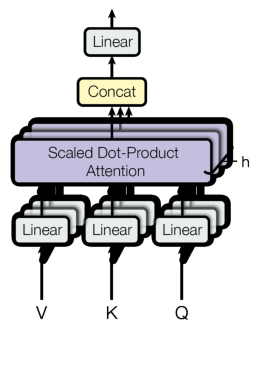

extracted_images\page2_img1.png
이 이미지는 **Transformer(트랜스포머) 모델의 인코더-디코더 구조**를 한눈에 보여주는 도식입니다. 전체적으로 **인코더(왼쪽)**가 입력을 처리해 표현을 만들고, **디코더(오른쪽)**가 그 표현을 바탕으로 다음 토큰을 예측하도록 동작하는 흐름을 설명합니다.

---

## 1) 전체 구조(좌측 인코더, 우측 디코더)
- **왼쪽 블록(Encoder Stack)**: 입력 문장을 받아 특징(표현)을 추출합니다.  
  - 그림에 **“N×”** 표기가 있어, 동일한 층이 여러 번 반복됨을 뜻합니다.
- **오른쪽 블록(Decoder Stack)**: 인코더 출력(메모리)을 참고하면서, 현재까지의 출력으로 다음 토큰을 생성합니다.  
  - 역시 **“N×”**로 반복되는 디코더 층 구성을 나타냅니다.
- 중앙 위쪽의 경로(디코더 상단)는 최종적으로 **출력 확률**을 계산하는 부분으로 연결됩니다.

---

## 2) 입력 측(아래쪽): Embedding + Positional Encoding
### Input Embedding
- 하단에 **“Input Embedding”**(연한 분홍색 박스)이 있으며, 입력


In [17]:
show_img_summarize(2)